In [ ]:
pip install matplotlib seaborn plotly scipy scikit-learn pandas numpy implicit ipykernel jupyter


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.9 MB/s eta 0:00:00
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933264 sha256=b5847b9e17f8332067c834291bffdab70df29357606dc7999c3c0496557828b7
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


# Book Recommendation System
### DS Assignment
---

## Problem Framing

**Task:** Given a user's chapter-reading history, recommend 10 books they should read next.

**Key decision — why "recommend a new book" and not "next chapter":**
- After exploring the data, only 0.05% of users read more than 1 chapter of the same book
- Sequential within-book signals are essentially absent
- The right framing is: **recommend a new book to start**, using genre and collaborative signals

**Assumptions:**
- Each chapter interaction = a signal of interest in that book and its genres
- No explicit ratings — all feedback is implicit (interaction = positive signal)
- No timestamps available — recency weighting is not possible

In [ ]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)

chapters = pd.read_csv("/content/chapters.csv")
interactions = pd.read_csv("/content/interactions.csv")
chapters["genre_list"] = chapters["tags"].str.split("|")

user_book = (
    interactions
    .groupby(["user_id", "book_id"])
    .size()
    .reset_index(name="interaction_count")
)

print(f"Chapters     : {len(chapters):,}")
print(f"Interactions : {len(interactions):,}")
print(f"Unique users : {interactions['user_id'].nunique():,}")
print(f"Unique books : {interactions['book_id'].nunique():,}")

Chapters     : 50,000
Interactions : 1,000,000
Unique users : 149,803
Unique books : 9,575


---
## Part 1 — Exploratory Data Analysis

In [ ]:
print("=== CHAPTERS SAMPLE ===")
print(chapters.head())
print("\nNull values:\n", chapters.isnull().sum())

=== CHAPTERS SAMPLE ===
   chapter_id  chapter_sequence_no  book_id  author_id published_date  \
0     2812946                    1   139726      66847     1990-03-22   
1     4330764                    2   139726      66847     1990-04-09   
2     2664499                    3   139726      66847     1990-04-07   
3     2260666                    4   139726      66847     1990-05-18   
4     6069976                    1   191772      62262     2008-07-30   

                                       tags  \
0                            Fantasy|Horror   
1      Fantasy|Young Adult|Literary Fiction   
2                                   Fantasy   
3                  Literary Fiction|Fantasy   
4  Horror|Young Adult|Romance|Graphic Novel   

                                      genre_list  
0                              [Fantasy, Horror]  
1       [Fantasy, Young Adult, Literary Fiction]  
2                                      [Fantasy]  
3                    [Literary Fiction, Fantasy]  

Chapters per book:
count    9575.00
mean        5.22
std         4.06
min         1.00
25%         3.00
50%         4.00
75%         6.00
max        20.00
dtype: float64


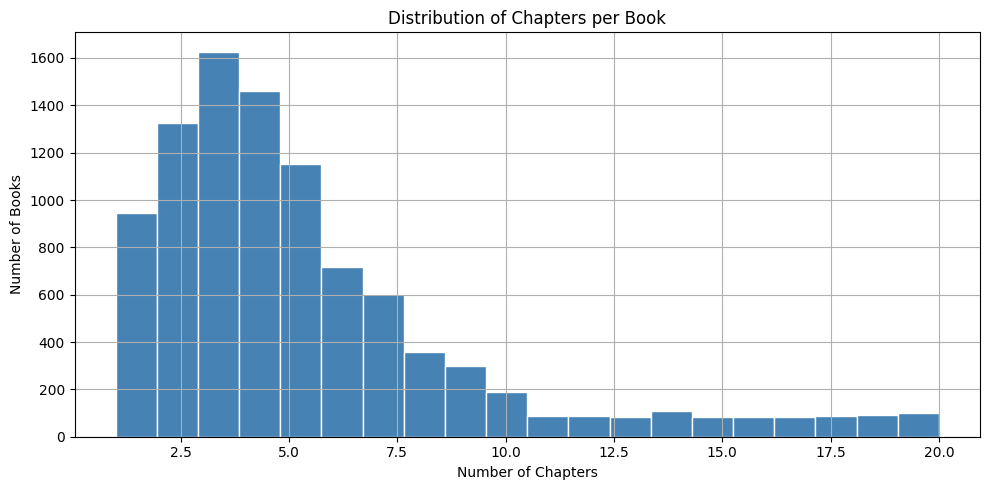

In [ ]:
chapters_per_book = chapters.groupby("book_id").size()
print("Chapters per book:")
print(chapters_per_book.describe().round(2))

plt.figure()
chapters_per_book.hist(bins=20, color='steelblue', edgecolor='white')
plt.title("Distribution of Chapters per Book")
plt.xlabel("Number of Chapters")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

Interactions per user:
count    149803.00
mean          6.68
std           2.57
min           1.00
25%           5.00
50%           6.00
75%           8.00
max          20.00
Name: interaction_count, dtype: float64


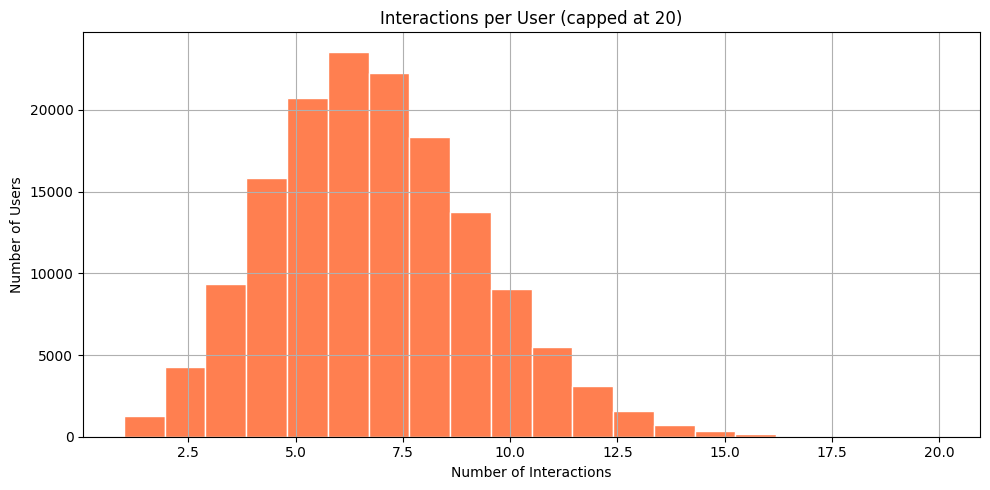

In [ ]:
interactions_per_user = user_book.groupby("user_id")["interaction_count"].sum()
print("Interactions per user:")
print(interactions_per_user.describe().round(2))

plt.figure()
interactions_per_user.clip(upper=20).hist(bins=20, color='coral', edgecolor='white')
plt.title("Interactions per User (capped at 20)")
plt.xlabel("Number of Interactions")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

Interactions per book:
count    9575.00
mean      104.44
std       123.83
min         2.00
25%        28.00
50%        49.00
75%       140.50
max      1166.00
Name: interaction_count, dtype: float64


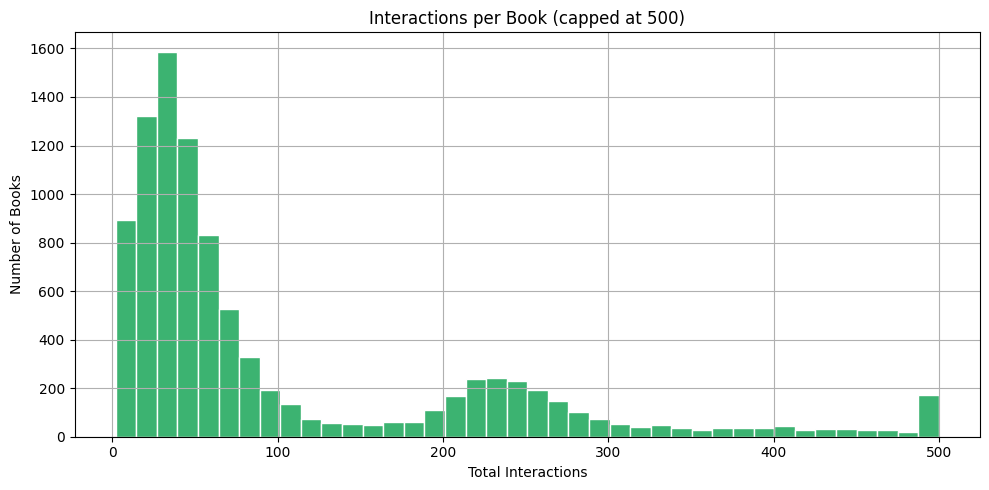

In [ ]:
interactions_per_book = user_book.groupby("book_id")["interaction_count"].sum()
print("Interactions per book:")
print(interactions_per_book.describe().round(2))

plt.figure()
interactions_per_book.clip(upper=500).hist(bins=40, color='mediumseagreen', edgecolor='white')
plt.title("Interactions per Book (capped at 500)")
plt.xlabel("Total Interactions")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

Users with only 1 book   : 1,255  (0.8%)
Users with <= 3 books    : 14,860 (9.9%)
Total users              : 149,803


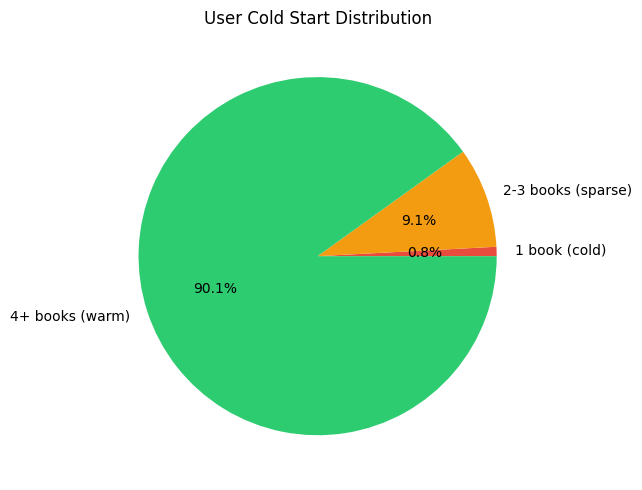

In [ ]:
books_per_user = user_book.groupby("user_id").size()
cold_1  = (books_per_user == 1).sum()
cold_3  = (books_per_user <= 3).sum()
total_u = len(books_per_user)

print(f"Users with only 1 book   : {cold_1:,}  ({cold_1/total_u*100:.1f}%)")
print(f"Users with <= 3 books    : {cold_3:,} ({cold_3/total_u*100:.1f}%)")
print(f"Total users              : {total_u:,}")

sizes  = [
    (books_per_user == 1).sum(),
    ((books_per_user >= 2) & (books_per_user <= 3)).sum(),
    (books_per_user >= 4).sum()
]
labels = ['1 book (cold)', '2-3 books (sparse)', '4+ books (warm)']
plt.figure(figsize=(7,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=['#e74c3c','#f39c12','#2ecc71'])
plt.title("User Cold Start Distribution")
plt.tight_layout()
plt.show()

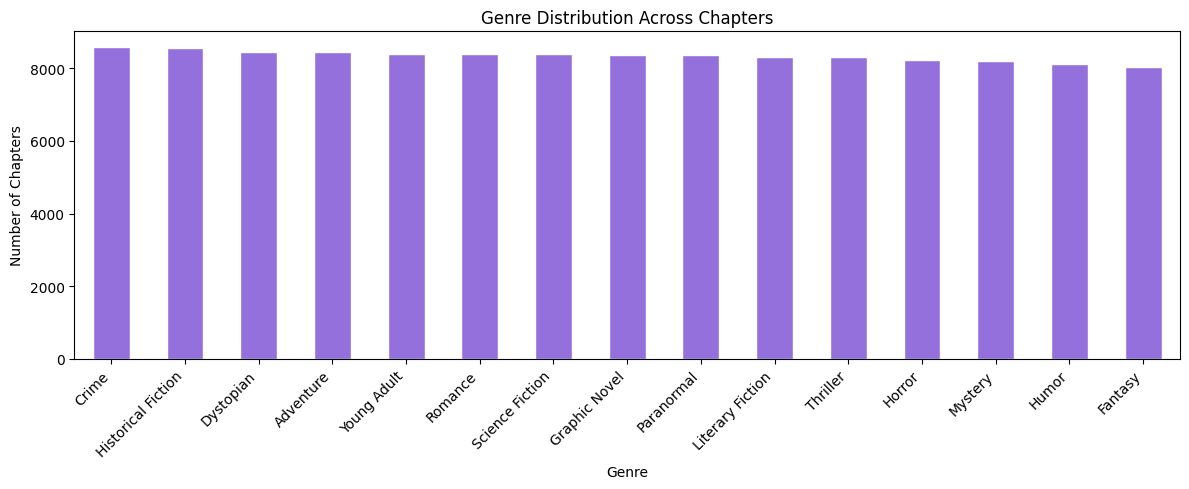

genre_list
Crime                 8589
Historical Fiction    8547
Dystopian             8448
Adventure             8445
Young Adult           8393
Romance               8389
Science Fiction       8387
Graphic Novel         8376
Paranormal            8359
Literary Fiction      8325
Thriller              8325
Horror                8235
Mystery               8203
Humor                 8130
Fantasy               8039
Name: count, dtype: int64


In [ ]:
all_genres = chapters["genre_list"].explode()
genre_counts = all_genres.value_counts()

plt.figure(figsize=(12, 5))
genre_counts.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title("Genre Distribution Across Chapters")
plt.xlabel("Genre")
plt.ylabel("Number of Chapters")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(genre_counts)

In [ ]:
merged = interactions.merge(
    chapters[["chapter_id", "book_id", "chapter_sequence_no"]],
    on=["chapter_id", "book_id"]
)
multi_chapter = merged.groupby(["user_id", "book_id"]).size()
pct_multi = (multi_chapter >= 2).mean() * 100

print(f"% users who read 2+ chapters of same book: {pct_multi:.3f}%")
print()
print("This is why 'next chapter' recommendation is not viable —")
print("almost no user reads multiple chapters of the same book.")

% users who read 2+ chapters of same book: 0.048%

This is why 'next chapter' recommendation is not viable —
almost no user reads multiple chapters of the same book.


---
## Part 2 — Model Architecture

### Two-Stage Hybrid Recommender

| Method | How it works | Strength |
|--------|-------------|----------|
| **Collaborative Filtering (ALS)** | Finds users with similar reading patterns | Captures taste similarity |
| **Content-Based Filtering** | Scores books by genre similarity to user history | Works for cold/sparse users |

**Score blending:** `final_score = 0.7 × CF + 0.3 × Content`

**Cold Start Strategy:**
- 0 interactions → global popularity fallback
- 1–2 interactions → pure content-based
- 3+ interactions → hybrid

In [ ]:
n_users = interactions['user_id'].nunique()
n_books = interactions['book_id'].nunique()
n_interactions = len(user_book)
sparsity = 1 - (n_interactions / (n_users * n_books))

print(f"Matrix size  : {n_users:,} users × {n_books:,} books")
print(f"Filled cells : {n_interactions:,}")
print(f"Total cells  : {n_users * n_books:,}")
print(f"Sparsity     : {sparsity*100:.4f}%")
print()
print("This extreme sparsity is why ALS is the right choice —")
print("it is specifically designed for implicit feedback matrices.")

Matrix size  : 149,803 users × 9,575 books
Filled cells : 999,520
Total cells  : 1,434,363,725
Sparsity     : 99.9303%

This extreme sparsity is why ALS is the right choice —
it is specifically designed for implicit feedback matrices.


---
## Part 3 — Training & Evaluation

In [ ]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
import scipy.sparse as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares

matplotlib.rcParams['figure.figsize'] = (10, 5)
print("All imports done!")

All imports done!


In [ ]:
# ─────────────────────────────────────────
# DATA LOADER
# ─────────────────────────────────────────
def load_data(chapters_path, interactions_path):
    chapters = pd.read_csv(chapters_path)
    interactions = pd.read_csv(interactions_path)
    chapters["genre_list"] = chapters["tags"].str.split("|")
    user_book = (
        interactions
        .groupby(["user_id", "book_id"])
        .size()
        .reset_index(name="interaction_count")
    )
    print(f"Loaded {len(chapters):,} chapters, {len(interactions):,} interactions")
    print(f"Users: {interactions['user_id'].nunique():,} | Books: {interactions['book_id'].nunique():,}")
    return chapters, interactions, user_book


# ─────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────
GENRES = [
    "Adventure", "Crime", "Dystopian", "Fantasy", "Graphic Novel",
    "Historical Fiction", "Horror", "Humor", "Literary Fiction",
    "Mystery", "Paranormal", "Romance", "Science Fiction",
    "Thriller", "Young Adult",
]

def build_book_profiles(chapters):
    book_genres = (
        chapters.groupby("book_id")["genre_list"]
        .apply(lambda x: list({g for genres in x for g in genres}))
    )
    mlb = MultiLabelBinarizer(classes=GENRES)
    matrix = mlb.fit_transform(book_genres)
    return pd.DataFrame(matrix, index=book_genres.index, columns=GENRES)

def build_user_profiles(user_book, book_profiles):
    user_profiles = {}
    for user, group in user_book.groupby("user_id"):
        valid_books = [b for b in group["book_id"] if b in book_profiles.index]
        if not valid_books:
            continue
        vecs = book_profiles.loc[valid_books].values
        weights = (
            group.set_index("book_id")
            .loc[valid_books, "interaction_count"]
            .values.astype(float)
        )
        user_profiles[user] = np.average(vecs, axis=0, weights=weights)
    return user_profiles


# ─────────────────────────────────────────
# COLLABORATIVE FILTER (ALS)
# ─────────────────────────────────────────
class ALSRecommender:
    def __init__(self, factors=64, iterations=20, regularization=0.1):
        self.model = AlternatingLeastSquares(
            factors=factors,
            iterations=iterations,
            regularization=regularization,
            use_gpu=False,
        )
        self.user_map = {}
        self.book_map = {}
        self.inv_book_map = {}
        self.matrix = None

    def fit(self, user_book_df):
        users = user_book_df["user_id"].unique()
        books = user_book_df["book_id"].unique()
        self.user_map = {u: i for i, u in enumerate(users)}
        self.book_map = {b: i for i, b in enumerate(books)}
        self.inv_book_map = {i: b for b, i in self.book_map.items()}
        rows = user_book_df["user_id"].map(self.user_map)
        cols = user_book_df["book_id"].map(self.book_map)
        data = user_book_df["interaction_count"].astype(float)
        self.matrix = sp.csr_matrix(
            (data, (rows, cols)), shape=(len(users), len(books))
        )
        print("Fitting ALS model...")
        self.model.fit(self.matrix)
        print("ALS training complete.")

    def recommend(self, user_id, n=200):
        if user_id not in self.user_map:
            return []
        uid = self.user_map[user_id]
        ids, scores = self.model.recommend(
            uid, self.matrix[uid], N=n, filter_already_liked_items=True
        )
        return [(self.inv_book_map[i], float(s)) for i, s in zip(ids, scores)]


# ─────────────────────────────────────────
# CONTENT FILTER
# ─────────────────────────────────────────
class ContentRecommender:
    def __init__(self, book_profiles, user_profiles):
        self.book_profiles = book_profiles
        self.user_profiles = user_profiles

    def recommend(self, user_id, read_books, n=200):
        if user_id not in self.user_profiles:
            return []
        user_vec = self.user_profiles[user_id].reshape(1, -1)
        unseen = self.book_profiles[~self.book_profiles.index.isin(read_books)]
        if unseen.empty:
            return []
        sims = cosine_similarity(user_vec, unseen.values)[0]
        top_idx = sims.argsort()[::-1][:n]
        return [(unseen.index[i], float(sims[i])) for i in top_idx]


# ─────────────────────────────────────────
# HYBRID RECOMMENDER
# ─────────────────────────────────────────
class HybridRecommender:
    def __init__(self, cf_model, cb_model, alpha=0.7, cold_start_threshold=3):
        self.cf = cf_model
        self.cb = cb_model
        self.alpha = alpha
        self.cold_start_threshold = cold_start_threshold

    @staticmethod
    def _normalize(score_dict):
        if not score_dict:
            return {}
        mn, mx = min(score_dict.values()), max(score_dict.values())
        if mx == mn:
            return {k: 1.0 for k in score_dict}
        return {k: (v - mn) / (mx - mn) for k, v in score_dict.items()}

    def recommend(self, user_id, user_book_df, popularity_fallback, n=10):
        read_books = set(
            user_book_df[user_book_df["user_id"] == user_id]["book_id"]
        )
        if len(read_books) == 0:
            return popularity_fallback[:n]
        cf_recs = self._normalize(dict(self.cf.recommend(user_id, n=200)))
        cb_recs = self._normalize(
            dict(self.cb.recommend(user_id, read_books, n=200))
        )
        alpha = self.alpha if len(read_books) >= self.cold_start_threshold else 0.0
        all_books = set(cf_recs) | set(cb_recs)
        scores = {
            b: alpha * cf_recs.get(b, 0.0) + (1 - alpha) * cb_recs.get(b, 0.0)
            for b in all_books
        }
        return sorted(scores, key=scores.get, reverse=True)[:n]


# ─────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────
def leave_one_out_split(user_book_df, seed=42):
    train_parts, test = [], {}
    for user, group in user_book_df.groupby("user_id"):
        if len(group) < 2:
            train_parts.append(group)
            continue
        held = group.sample(1, random_state=seed)
        test[user] = int(held["book_id"].values[0])
        train_parts.append(group.drop(held.index))
    return pd.concat(train_parts, ignore_index=True), test

def evaluate_batch(cf_model, test_dict, k=10):
    print(f"  Running batch evaluation for {len(test_dict):,} users...")
    known_users = {u: cf_model.user_map[u] for u in test_dict if u in cf_model.user_map}
    user_ids = list(known_users.keys())
    user_indices = list(known_users.values())
    batch_size = 5000
    hits, reciprocal_ranks = 0, []
    for start in range(0, len(user_indices), batch_size):
        end = min(start + batch_size, len(user_indices))
        batch_uids = user_indices[start:end]
        batch_user_ids = user_ids[start:end]
        user_vecs = cf_model.matrix[batch_uids]
        batch_ids, _ = cf_model.model.recommend(
            batch_uids, user_vecs, N=k, filter_already_liked_items=True,
        )
        for i, user in enumerate(batch_user_ids):
            true_book = test_dict[user]
            rec_book_ids = [cf_model.inv_book_map[idx] for idx in batch_ids[i]]
            if true_book in rec_book_ids:
                hits += 1
                reciprocal_ranks.append(1.0 / (rec_book_ids.index(true_book) + 1))
            else:
                reciprocal_ranks.append(0.0)
        print(f"  Progress: {end:,} / {len(user_indices):,}", end="\r")
    total = len(reciprocal_ranks)
    print(f"\n  Done evaluating {total:,} users.")
    return {
        "HR@K": hits / total,
        "MRR":  sum(reciprocal_ranks) / total,
        "K":    k,
        "N":    total,
    }

print("All classes and functions ready!")

All classes and functions ready!


In [ ]:
from scipy.sparse import coo_matrix
from implicit.als import AlternatingLeastSquares

user_book["user_id"] = user_book["user_id"].astype("category").cat.codes
user_book["book_id"] = user_book["book_id"].astype("category").cat.codes

user_book = user_book.sort_values("interaction_count", ascending=False).head(500000)

book_profiles = build_book_profiles(chapters)
user_profiles = build_user_profiles(user_book, book_profiles)

train_df, test_dict = leave_one_out_split(user_book)

sparse_matrix = coo_matrix((
    train_df["interaction_count"],
    (train_df["user_id"], train_df["book_id"])
))

cf = AlternatingLeastSquares(factors=32, iterations=10, regularization=0.1)
cf.fit(sparse_matrix)

cb = ContentRecommender(book_profiles, user_profiles)

popularity = (
    train_df.groupby("book_id")["interaction_count"]
    .sum()
    .nlargest(1000)
    .index.tolist()
)

hybrid = HybridRecommender(cf, cb, alpha=0.7, cold_start_threshold=3)

print("Training complete")

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.023070335388183594 seconds
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

Training complete


In [ ]:
from scipy.sparse import coo_matrix

def evaluate_batch(cf_model, test_dict, train_df, k=10):
    user_items = coo_matrix((
        train_df["interaction_count"],
        (train_df["user_id"], train_df["book_id"])
    )).tocsr()

    hits, rr, n = 0, 0, 0

    for user, true_item in test_dict.items():
        if user >= user_items.shape[0]:
            continue

        try:
            recs = cf_model.recommend(user, user_items[user], N=k)
        except Exception as e:
            continue

        rec_items = [item for item, _ in recs]

        if true_item in rec_items:
            hits += 1
            rank = rec_items.index(true_item) + 1
            rr += 1 / rank

        n += 1

    return {
        "HR@K": hits / n if n else 0,
        "MRR": rr / n if n else 0,
        "N": n
    }

In [ ]:
def recommend(self, user_id, user_book_df, popularity_fallback, n):
    read_books = set(user_book_df[user_book_df["user_id"] == user_id]["book_id"])

    if len(read_books) == 0:
        return popularity_fallback[:n]

    user_items = coo_matrix((
        user_book_df["interaction_count"],
        (user_book_df["user_id"], user_book_df["book_id"])
    )).tocsr()

    cf_raw = self.cf.recommend(user_id, user_items[user_id], N=200)
    cf_recs = self._normalize(dict(cf_raw))

    cb_recs = self._normalize(
        dict(self.cb.recommend(user_id, read_books, n=200))
    )

    scores = {}

    for item, score in cf_recs.items():
        scores[item] = self.alpha * score

    for item, score in cb_recs.items():
        scores[item] = scores.get(item, 0) + (1 - self.alpha) * score

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return [item for item, _ in ranked if item not in read_books][:n]